In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

In [7]:
df = pd.read_csv('titanic_toy.csv')

In [19]:
df.isnull().sum()
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [48]:
# now we can split the data 
x_train,x_test,y_train,y_test = train_test_split(df.iloc[:,0:3],df['Survived'],test_size=0.2,random_state=5)

In [49]:
x_train.head()

,Age,Fare,Family
887,19.0,30.0000,0
416,34.0,32.5000,2
479,2.0,12.2875,1
134,25.0,13.0000,0
588,22.0,8.0500,0


In [50]:
# now we will replace all the missing values using sample 
x_train['Age_imputed'] = x_train['Age']

In [51]:
x_test['Age_imputed'] = x_test['Age']

In [52]:
x_train.head()

,Age,Fare,Family,Age_imputed
887,19.0,30.0000,0,19.0
416,34.0,32.5000,2,34.0
479,2.0,12.2875,1,2.0
134,25.0,13.0000,0,25.0
588,22.0,8.0500,0,22.0


In [53]:
# now we can apply our imputation on the age imputed column 
x_train['Age_imputed'][x_train['Age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values

C:\Users\singl\AppData\Local\Temp\ipykernel_12532\3894640259.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['Age_imputed'][x_train['Age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
C

In [54]:
x_train.isnull().sum()

Age            147
Fare            38
Family           0
Age_imputed      0
dtype: int64

In [55]:
# we can see that we added all the values on x_train age at random and we can do this same with our x_test also 
x_test['Age_imputed'][x_test['Age_imputed'].isnull()] = x_test['Age'].dropna().sample(x_test['Age'].isnull().sum()).values

C:\Users\singl\AppData\Local\Temp\ipykernel_12532\284437823.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_test['Age_imputed'][x_test['Age_imputed'].isnull()] = x_test['Age'].dropna().sample(x_test['Age'].isnull().sum()).values
C:\Use

In [56]:
x_test.isnull().sum()

Age            30
Fare            7
Family          0
Age_imputed     0
dtype: int64

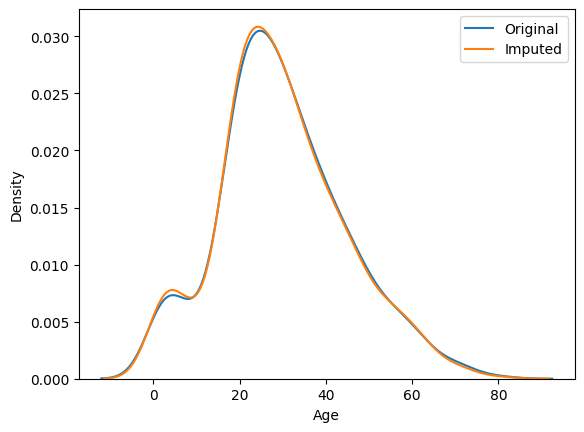

In [57]:
# now we can see distribution plot also 
sns.kdeplot(x_train['Age'])
sns.kdeplot(x_train['Age_imputed'])
plt.legend(labels=['Original','Imputed'])
plt.show()

In [ ]:
# we can see there are not much change in the distribution 
# we can do this for categorical data as well 